وقتی داده ها فیلتر شدند این برنامه نمودار تولید بر اساس دما را برای تمام واحدهای تولیدی رسم کرده و داده های مربوط به آخرین سری تولید و داده های انتخاب شده توسط فیلتر پنجم را نیز مشخص میکند. 

In [4]:
import os
import sys

import pandas as pd
import plotly.graph_objects as go

import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor, LinearRegression
current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)
from src.models.filter_data.filter_data import *
from src.models.filter_data.feature_adder import *

In [5]:
temp_feature = "temperature"
csv_read_path = os.path.join(project_root, "data", "processed", "semi_processed.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')
df_c = df

In [33]:
import numpy as np
import pandas as pd

def grid_envelope_points(
        df,
        x_col,
        y_col,
        z_col,
        grid_size_x,
        grid_size_y,
        p1=0.9,
        p2=1.0
    ):
    """
    df: DataFrame
    x_col, y_col : مختصات 2D
    z_col        : مقدار برای تشکیل envelope
    grid_size_x, grid_size_y : اندازه شبکه
    p1, p2       : درصدهای تعیین envelope (۰ تا ۱)

    خروجی:
        DataFrame شامل همهٔ نقاطی که Z آن‌ها بین low و high باشد.
    """

    X = df[x_col].values
    Y = df[y_col].values
    Z = df[z_col].values

    xmin, xmax = X.min(), X.max()
    ymin, ymax = Y.min(), Y.max()

    nx = int(np.ceil((xmax - xmin) / grid_size_x))
    ny = int(np.ceil((ymax - ymin) / grid_size_y))

    envelope_points = []   # اینجا همه نقاط بیشینه جمع می‌شود

    # پیمایش سلول‌های شبکه
    for ix in range(nx):
        for iy in range(ny):

            x_start = xmin + ix * grid_size_x
            x_end   = x_start + grid_size_x

            y_start = ymin + iy * grid_size_y
            y_end   = y_start + grid_size_y

            mask = (
                (X >= x_start) & (X < x_end) &
                (Y >= y_start) & (Y < y_end)
            )

            cell_df = df[mask]

            if len(cell_df) == 0:
                continue

            # محاسبه درصدهای low و high این سلول
            low  = np.percentile(cell_df[z_col], p1 * 100)
            high = np.percentile(cell_df[z_col], p2 * 100)

            # انتخاب نقاط envelope این سلول
            env = cell_df[
                (cell_df[z_col] >= low) &
                (cell_df[z_col] <= high)
            ]

            envelope_points.append(env)

    # ادغام همه envelopeهای سلول‌ها
    if envelope_points:
        envelope_df = pd.concat(envelope_points, axis=0).reset_index(drop=True)
    else:
        envelope_df = pd.DataFrame()

    return envelope_df


In [42]:
import plotly.express as px

def show(df, save=False, param=None, ass=""):
    # تغییر به نمودار سه بعدی
    df_m1 = grid_envelope_points(
        df,
        x_col="temperature",
        y_col="humidity",
        z_col="generation",
        grid_size_x=2,
        grid_size_y=2,
        p1=0.9,
        p2=0.99
    )
    fig = px.scatter_3d(
        df_m1,
        x="temperature",
        y="humidity",
        z="generation",   # محور سوم
        color='generation',  # رنگ می‌تواند همان generation باشد
        title='Generation over temp & hum',
        labels={
            'generation': 'Generation',
            'temperature': 'Temperature',
            'humidity': 'Humidity'
        },
        hover_data=['generation', 'temperature', 'humidity'],
    )
    fig.update_traces(marker=dict(size=2))
    if save:
        fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter7{ass}/{param['name']}-{param['code']}.html")
    else:
        fig.show()


In [40]:
import plotly.express as px

def show_2(df_m, save=False, param=None, ass=""):
    # تغییر به نمودار سه بعدی
    df_m1 = df_m.copy()
    df_m1.sort_values(by="humidity",inplace=True)
    df_m1['new_col'] = (df_m1['temperature'] // 5).astype(int)
    
    
    import plotly.graph_objects as go

    fig = go.Figure()
    
    for i in range(min(df_m1['new_col']), max(df_m1['new_col']) + 1):
        df_temp = df_m1[df_m1['new_col'] == i]
    
        fig.add_trace(
            go.Scatter(
                x=df_temp["humidity"],
                y=df_temp["generation"],
                mode='lines',
                marker=dict(size=2),
                name=f"group {i}",
                hovertext=[
                    f"gen: {g}, temp: {t}, hum: {h}"
                    for g, t, h in zip(df_temp['generation'], df_temp['temperature'], df_temp['humidity'])
                ]
            )
        )
    
    fig.update_layout(
        title='Generation over hum',
        xaxis_title="Humidity",
        yaxis_title="Generation"
    )
    
    if save:
        fig.write_html(
            f"{project_root}/src/visualization/unit_figs/filter7{ass}/{param['name']}-{param['code']}.html")
    else:
        fig.show()



In [43]:
power_plants = df_c[['name', 'code']].drop_duplicates()

for row in power_plants.itertuples():
    name_plot, code_plot = row.name, row.code
    #print(name_plot, code_plot)
    ds_n_c_plot = Data_selector(Data_selector(df_c).select_peaks(goodness=1))
    df_n_c_plot = ds_n_c_plot.filter_name_code(name_plot, code_plot)
    try:
        show(df_n_c_plot, save=True, param={"name": name_plot, "code": code_plot})
    except Exception as e:
        print(name_plot,code_plot)
        print(e)

In [60]:
df_m = grid_envelope_points(
        df_n_c_plot,
        x_col="temperature",
        y_col="humidity",
        z_col="generation",
        grid_size_x=2,
        grid_size_y=2,
        p1=0.9,
        p2=0.99
    )
model = LinearRegression()

In [61]:
X = df_m[["temperature","humidity"]]

In [62]:
y = df_m[["generation"]]

In [69]:
model.fit(X,df_m[["generation"]])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_p = model.predict(X)

In [65]:
from src.models import utils

utils.compute_relative_rmse(y_p,y)

np.float64(4.881493280494296)

In [66]:
r = y_p - y

(array([ 49., 498., 259.,  13.,   4.,   5.,   1.,   1.,   1.,   6.]),
 array([-12.87264127,  -6.18308561,   0.50647006,   7.19602572,
         13.88558139,  20.57513705,  27.26469272,  33.95424838,
         40.64380405,  47.33335972,  54.02291538]),
 <BarContainer object of 10 artists>)

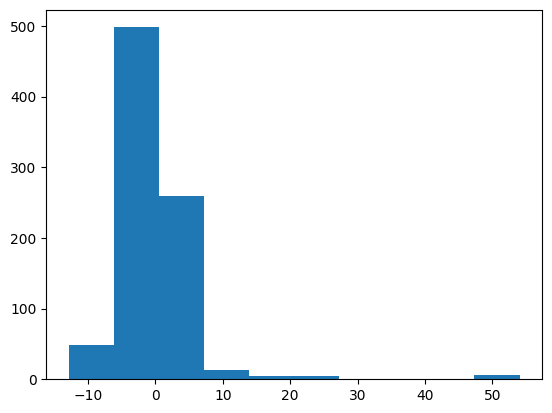

In [68]:
plt.hist(r)

In [ ]:
model